# Beyond Pace: Pace-Driven Running vs Navigation-Driven Sports

### Part 2 - Exploratory Data Analysis (EDA)

---

Here we will analyze our datasets to discover patterns and test hypotheses using visualization and ____

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\viver\AppData\Local\Temp\ipykernel_26024\687462750.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# завантажуємо підготовлений датасет

df_combined = pd.read_csv("../data/processed/garmin_combined.csv")

In [3]:
df_combined.head()

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Avg Power,Max Power,Grit,Flow,Total Strokes,Avg. Swolf,Avg Stroke Rate,Body Battery Drain,Min Temp,Max Temp
0,Trail Running,2026-05-17 11:56:00,False,"🦊3,5 training",8.38,479.0,01:06:42,151.0,187.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Trail Running,2026-05-16 14:20:24,False,"🦊3,5 training",9.64,607.0,01:49:50,139.0,183.0,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Trail Running,2026-05-09 11:45:01,False,🦊 144 training,10.90,740.0,02:31:34,130.0,175.0,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trail Running,2026-05-03 10:16:03,False,Lutskyi raion Running,4.53,299.0,00:49:57,136.0,174.0,2.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Trail Running,2026-05-02 12:04:59,False,"🦊ARDF, ЧУ 3,5, Луцьк",11.35,617.0,01:54:51,141.0,186.0,3.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# після read_csv Date тип знову став object, переводимо
df_combined["Date"] = pd.to_datetime(df_combined["Date"])

### EDA

#### Distribution of Distance by Athlete:

c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

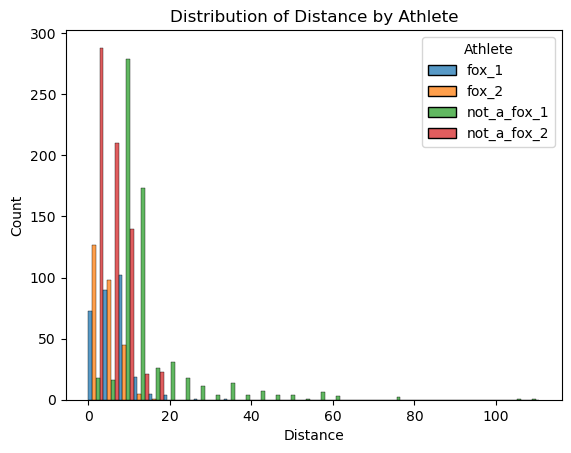

In [5]:
# Гістограма розподілу дистанцій

sns.histplot(data = df_combined, x="Distance", hue="Athlete", bins=30, multiple="dodge")
plt.title("Distribution of Distance by Athlete")

plt.savefig("../images/Distribution_of_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

Бачимо, що найбільш схожу кількість активностей всі атлети мають на дистанціях 6-7 км. Та загалом fox_1 бігає довщі дистанції, а fox_2 частіше коротші, а атлет not_a_fox має найбільшу кількість коротких пробіжок 1-3 км, що може пояснюватись більшим розміром його датасету (682 записи)

Як видно, найбільшу кількість пробіжок мають not_a_fox_1 та not_a_fox_2. Але not_a_fox_1 бігає дистанції більше 10км (і навіть 100+), а not_a_fox_2 переважно бігає дистанції близько 5км. 
Найдовші дистанції має not_a_fox_1. 
fox_2 найбільше записів має ... 
________

#### Distribution of Pace by Athlete:

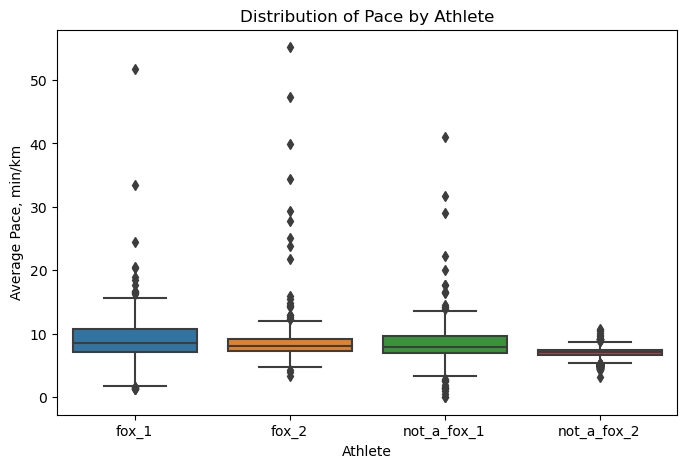

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Avg Pace num"

)
plt.title("Distribution of Pace by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/Distribution_of_Pace.png", dpi=300, bbox_inches="tight")
plt.show()

Боксплот відображає Average Pace - це середній темп, він показує, скільки хвилин спортсмен витрачав на 1 км. Менше значення означає швидший рух. Але для орієнтування та ARDF темп не можна трактувати лише як фізичну швидкість, бо на нього сильно впливають навігація, рельєф і складність дистанції.

#### Distribution of Avg HR by Athlete:

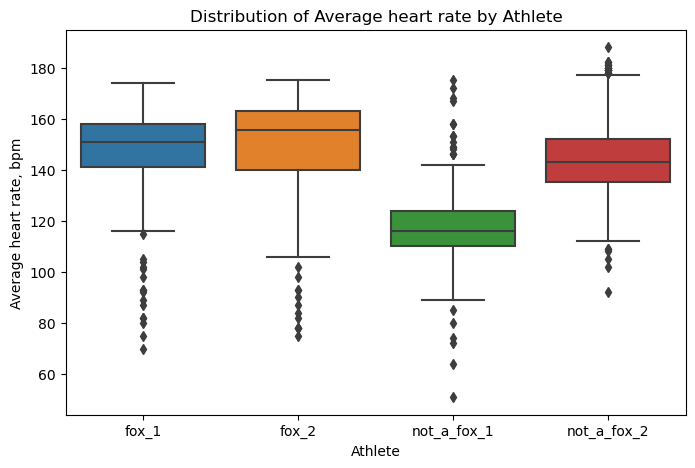

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Avg HR"

)
plt.title("Distribution of Average heart rate by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Average heart rate, bpm")

plt.savefig("../images/Distribution_of_HR.png", dpi=300, bbox_inches="tight")
plt.show()

Розподіл середніх показників серцебиття для fox_1 та fox_2 незначно відрізняється, хоч fox_2 має трохи ширший діапазон значень, і not_a_fox_2  показує меншу сереню частоту серцебиття і менше коливань.

Avg HR для fox_1 та fox_2 мають більше викидів вниз (80-100 уд/хв) - це не відпочинок, як могло б здатись, а специфіка Navigation Driven спорту, де є періоди простого подолання деяких ділянок, і окремі етапи "набігання" (прискорення), або навпаки уповільнення.

#### Distribution of Total Ascent by Athlete:

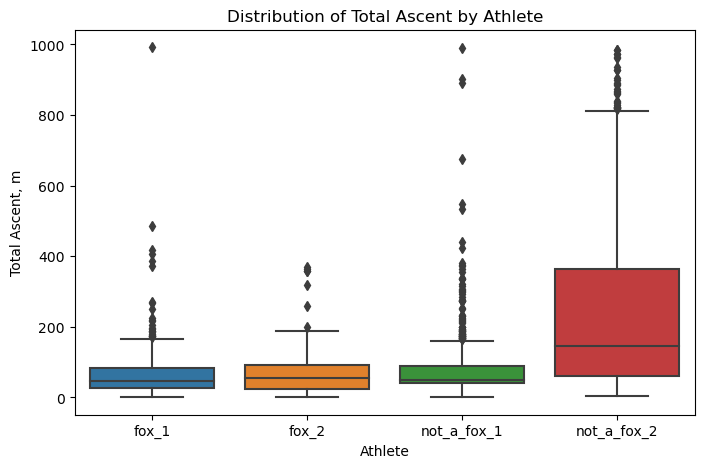

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Total Ascent"

)
plt.title("Distribution of Total Ascent by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Total Ascent, m")

plt.savefig("../images/Distribution_of_TotalAscent.png", dpi=300, bbox_inches="tight")
plt.show()

Тут відображено Загальний підйом - 
Розподіл набору висоти показав, що зазвичай not_a_fox_2 бігає з найбільшим набором висоти, тоді як більшість підйомів для  fox_1 та fox_2 - дуже незначні і приблизно однакові.
Припускаємо, що not_a_fox_2 проживає в гірській місцевості і тому має медіану Total Ascent близьку до 200, на противагу fox_1 та fox_2 з їх медіаною близько 50м. Це ніби і вказує що fox_1, fox_2 не з гірської місцевості, але враховуючи контекст даних маємо для цього і інше пояснення - Navigation Driven саме означає, що спортсмени свідомо прокладаюсь собі шлях уникаючи невиправданих перепадів висоти, акі дають швидке виснаження і втрату подальшої швидкості через втому, це про читання рельєфу на карті і розумне прийняття рішень - глибокі яри, балки, болота, пагорби та височини - невід'ємна частина Navigation Driven дисциплін.


#### Correlation matrix — we'll see which metrics are related to each other:

In [9]:
# побачимо, які метрики пов’язані між собою

cols = ["Distance", "Time_hours", "Avg Pace num", "Avg HR", "Total Ascent", "Calories"]
corr_matrix = df_combined[cols].corr()
corr_matrix

,Distance,Time_hours,Avg Pace num,Avg HR,Total Ascent,Calories
Distance,1.000000,0.308118,-0.015601,-0.181003,0.191201,0.131066
Time_hours,0.308118,1.000000,-0.023014,-0.295540,0.027426,0.145245
Avg Pace num,-0.015601,-0.023014,1.000000,-0.354997,-0.098387,0.060673
Avg HR,-0.181003,-0.295540,-0.354997,1.000000,0.090142,0.042156
Total Ascent,0.191201,0.027426,-0.098387,0.090142,1.000000,0.292237
Calories,0.131066,0.145245,0.060673,0.042156,0.292237,1.000000


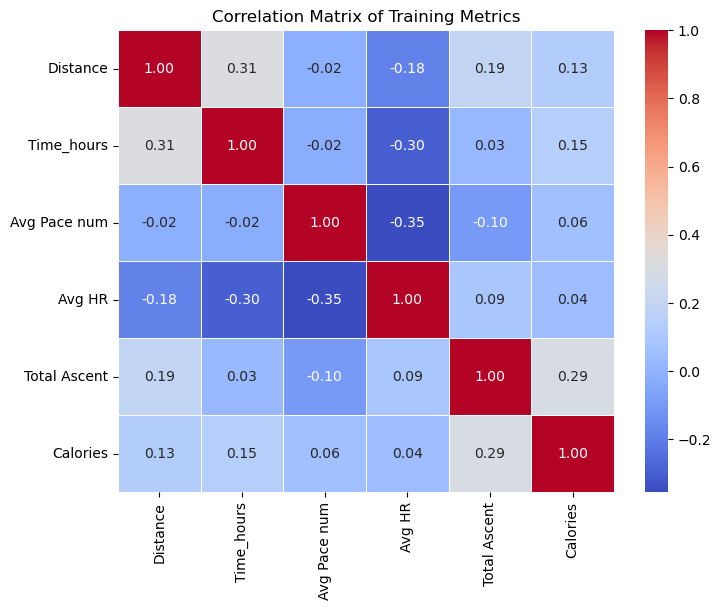

In [10]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidth=0.5
)
plt.title("Correlation Matrix of Training Metrics")
plt.savefig("../images/CorrelationMatrix_of_TrainingMetrics.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation Matrix 
("Distance", "Time_hours", "Avg Pace num", "Avg HR", "Total Ascent", "Calories"):

0.9 - Distance та Time_hours - дуже сильний зв'язок

0.89 - Distance та Calories - сильний зв'язок

0.83 - Time_hours та Calories - сильний зв'язок

0.59 - Total Ascent та Calories - помітний позитивний зв’язок (середньо-сильний)

0.51 - Total Ascent та Distance - помітний позитивний зв’язок (середньо-сильний)

0.37 - Total Ascent та Time_hours - помірний позитивний зв’язок

0.25 - Avg HR та Calories - слабкий позитивний зв’язок

0.19 - Avg Pace num та Time_hours - слабкий позитивний зв’язок

0.18 - Avg HR та Distance - слабкий позитивний зв’язок

0.06 - Avg HR та Time_hours - майже немає лінійного зв’язку

0.01 - Avg Pace num та Calories - майже немає лінійного зв’язку

-0.05 - Total Ascent та Avg HR - майже немає лінійного зв’язку

-0.1 - Total Ascent та Avg Pace num - майже немає лінійного зв’язку

-0.31 - Avg HR та Avg Pace num - помірний негативний зв’язок


Коротко - значення близькі до +1 говорять що ці змінні схильні зростати разом, якщо ближче до -1 одна зі змінних буде зростати, а інша зменшуватись, і якщо значення близьке до 0 то між цими змінними нема лінійної залежності.

Але. Всі в нашому дослідженні Avg Pace num, Avg HR, Calories пов'язані не лише з фізичною підготовкою, але і залежать від рельєфу, набору висоти, складності орієнтування.

Зокрема, маємо кореляцію -0.31 між Avg HR та Avg Pace num - зв’язок слабкий, бо на Avg HR має вплив також і Total Ascent, рельєф загалом, складність орієнтування, спека чи важливість старту.

#### Scatter plot для візуалізації кореляцій між Total Ascent та Avg Pace num

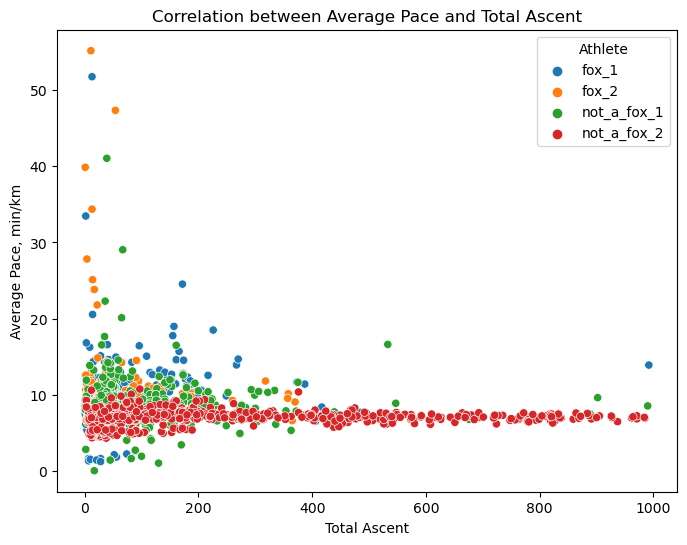

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data = df_combined, 
            x="Total Ascent", 
            y="Avg Pace num",
            hue="Athlete"
)
plt.title("Correlation between Average Pace and Total Ascent")
plt.xlabel("Total Ascent")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/CorrelationAvgPace_TotalAscent.png", dpi=300, bbox_inches="tight")
plt.show()

Як ми вже припустили - not_a_fox_2 житель гірської місцевості, звик бігати з великим набором висоти і тут бачимо що його темп дійсно є стабільним, навіть за умови сильного підйому. В той же час fox_1 і fox_2 мають помітні викиди і без набору висоти  - Avg Pace >20 min/km, це якраз навігаційні активності — рельєф малий, але темп непередбачуваний. ARDF, орієнтування -це спершу пошук, читання карти  і вже потім швидкість. Так ми ще раз стикаємось з тим самим Beyond Pace у нашому дослідженні.

#### Scatter plot для візуалізації кореляцій між Avg Pace num та HR scatter:

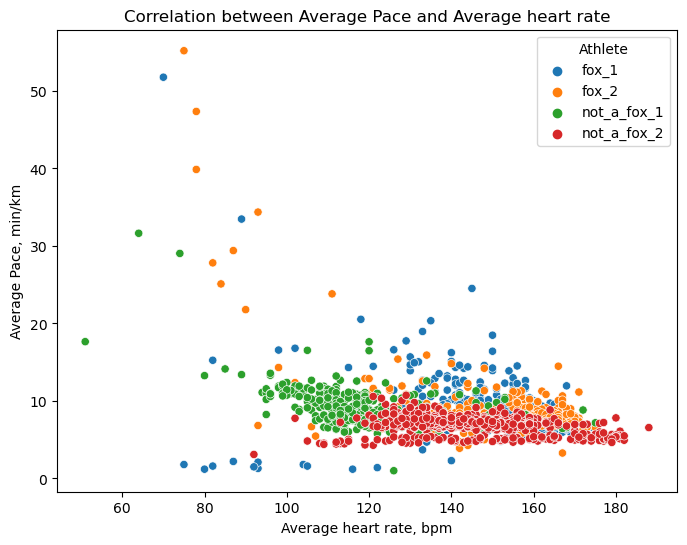

In [12]:
# Pace vs HR scatter — чи підтверджує кореляцію візуально

plt.figure(figsize=(8, 6))

sns.scatterplot(data = df_combined, 
            x="Avg HR", 
            y="Avg Pace num",
            hue="Athlete"
)
plt.title("Correlation between Average Pace and Average heart rate")
plt.xlabel("Average heart rate, bpm")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/CorrelationAvgPace_AvgHR.png", dpi=300, bbox_inches="tight")
plt.show()

Бачимо,що для not_a_fox_2 високий HR відповідає високому темпу. І на противагу цьому - для fox_1, fox_2 при будь-якому пульсі розкид Pace є великим і непердбачуваним. Ми знов маємо наочну демонстрацію navigation effect.

In [13]:
df_combined["Activity Type"].value_counts()

Activity Type
Running              1606
Trail Running         145
Other                  80
Treadmill Running      36
Indoor Running         10
Name: count, dtype: int64

#### Часовий аналіз. Line plot кілометражу по місяцях

c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

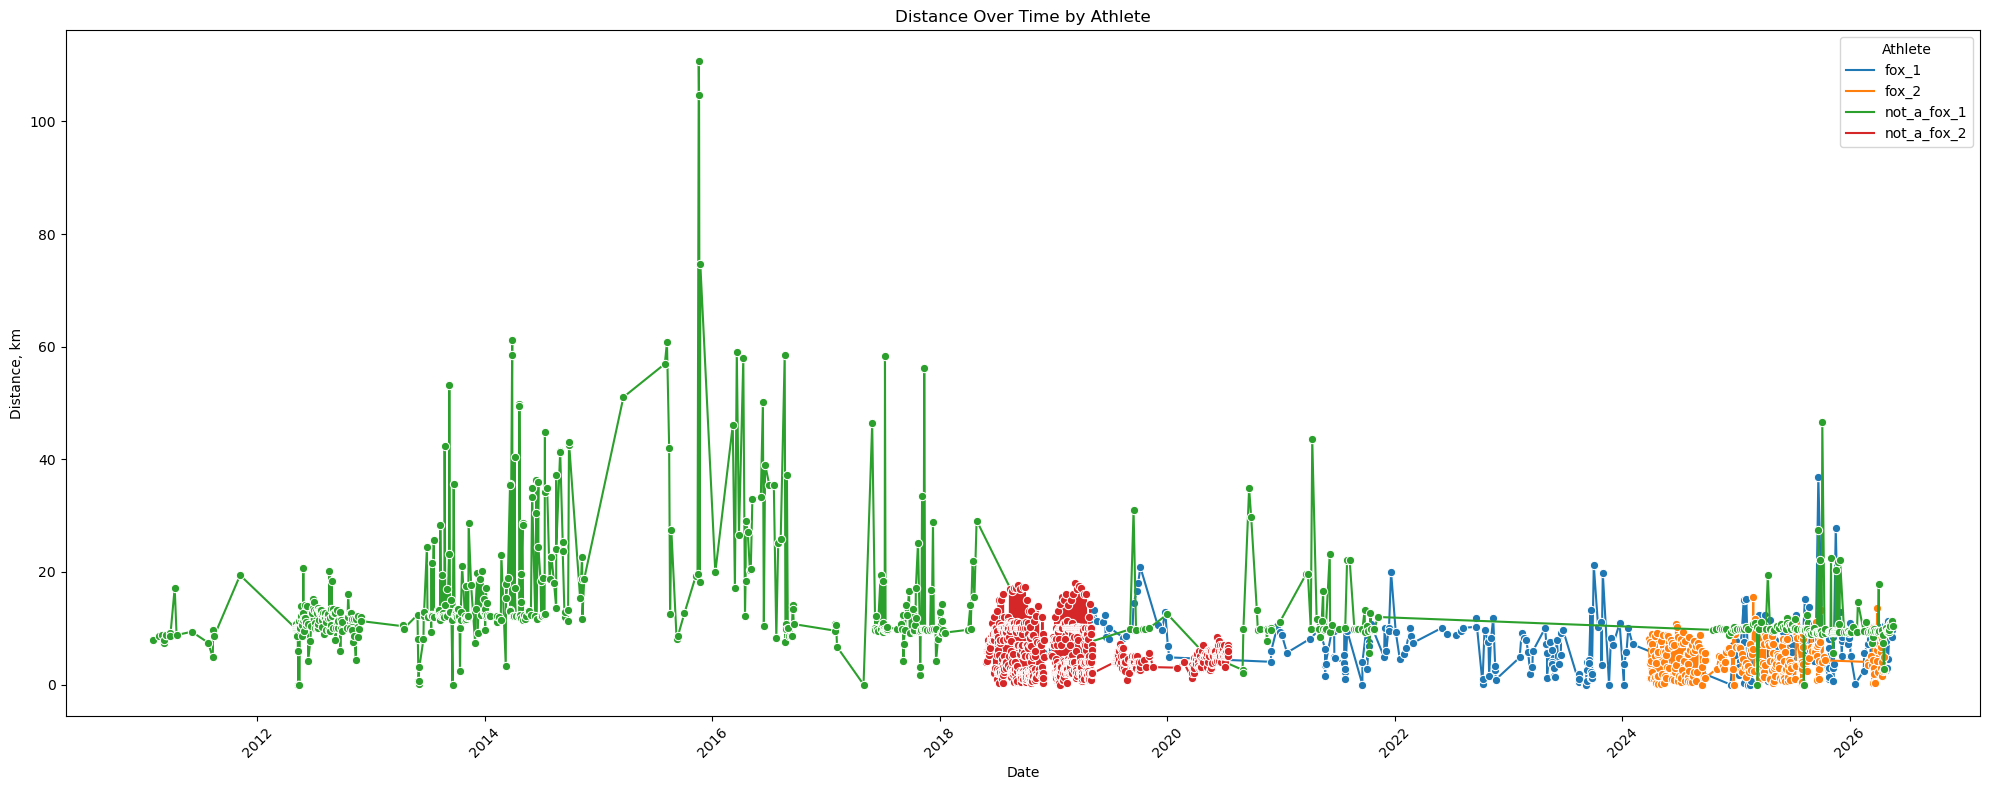

In [14]:
# як змінювалась Distance по датах

plt.figure(figsize=(20, 8))

sns.lineplot(
    data=df_combined,
    x="Date",
    y="Distance",
    hue="Athlete",
    marker="o"
)
plt.title("Distance Over Time by Athlete")
plt.xlabel("Date")
plt.ylabel("Distance, km")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/DistanceOverTime.png", dpi=300, bbox_inches="tight")
plt.show()

Щомісячний кілометраж для fox_1

Щомісячний кілометраж для fox_2:

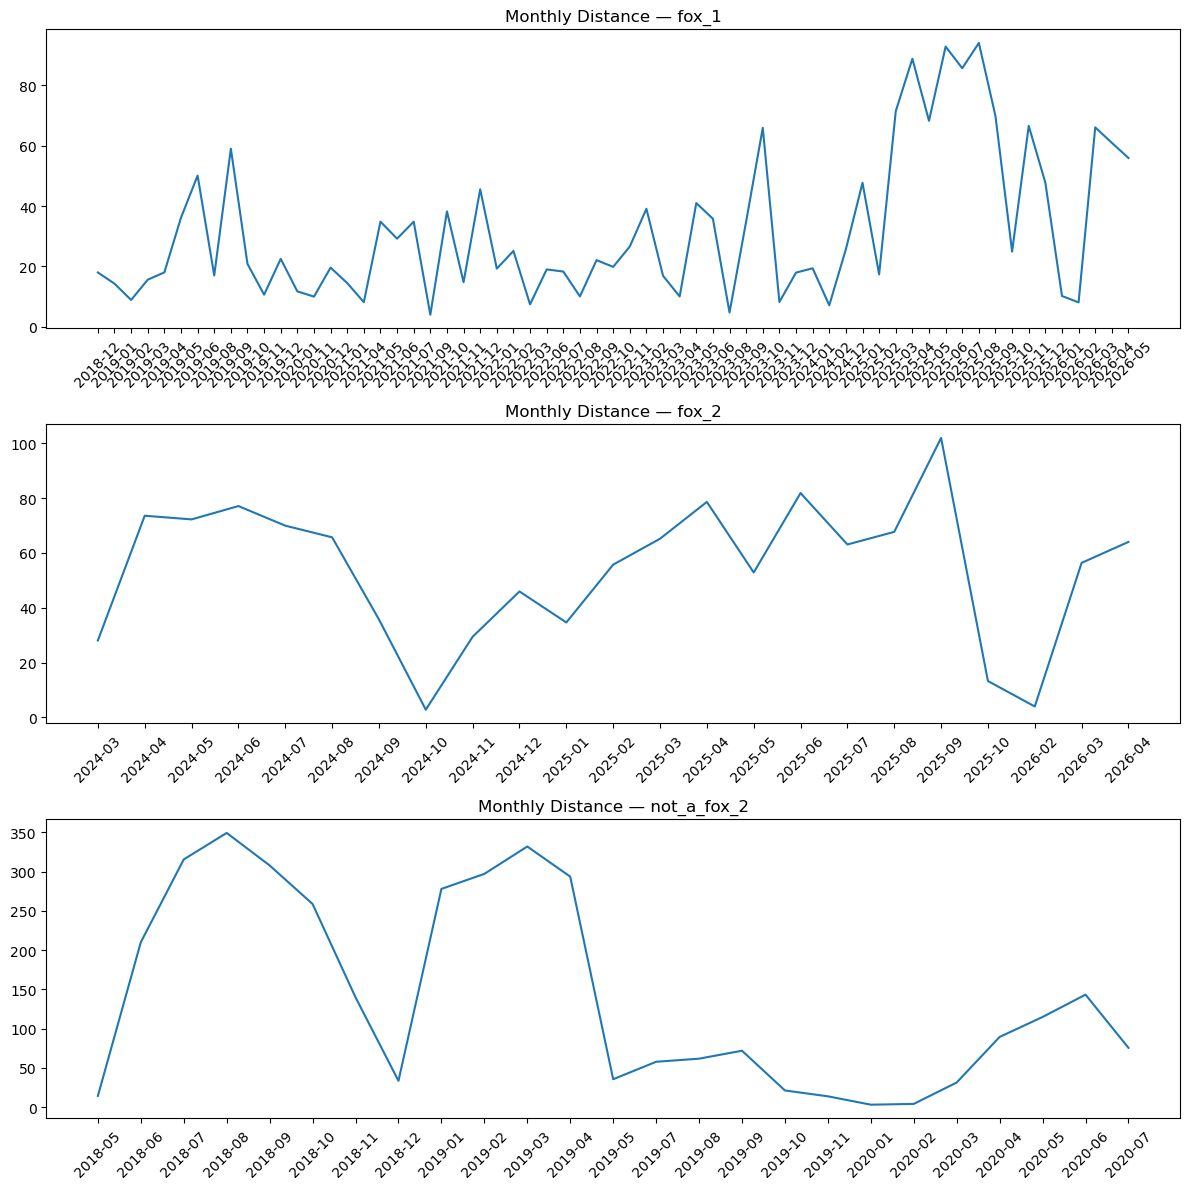

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
athletes = ["fox_1", "fox_2", "not_a_fox_2"]


for i in range(3):
    df_athlete = df_combined[df_combined["Athlete"] == athletes[i]].copy()
    df_athlete["YearMonth"] = df_athlete["Date"].dt.to_period("M").astype(str)
    monthly = df_athlete.groupby("YearMonth")["Distance"].sum().reset_index()
    axes[i].plot(monthly["YearMonth"], monthly["Distance"])
    axes[i].set_title(f"Monthly Distance — {athletes[i]}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../images/MonthlyDistance_byAthlete.png", dpi=300, bbox_inches="tight")
plt.show()

Почнемо з fox_2 - на графіку період в 2 роки, де легко читаються піки активності у серпні, з поступовим нарощенням напередодні, і подальшим спадом, що відповідає завершенню змагального сезону. 2 зимові періоди зовсім не схожі між собою, скоріше за все це повязано з наявністю/відсутністю снігу в різні роки. Це також один з наших navigation effects - сліди на снігу унеможливлюють тренування, є також і технічна сторона - робота приймачів/передавачів в умовах вологості та низьких температур.

Графік для fox_1 покриває тривалий часовий проміжок, тому читається складніше, деталі легко пропустити. Але вже знаючи патерн по графіку fox_2 - можна відстежити таку ж "зимову сплячку", і весняно-літні піки. Але тут бачимо і осінні піки - можливо, це типово бігові патерни закінчення бігового ссезону в жовтні-листопаді, марафони, можливо більше орієнтування, аніж ARDF, там теж сезон триває довше. Помітно також, що fox_1 має чимало пропусків з записах - від 1 до 10 місяців.

not_a_fox_1

Графік для not_a_fox_2 відображає 2річний період. Перший рік значно активніший. Обидва мають різдвяний спад, весняно-літній підйом. Між першим та другим роком перелам надзвичайно різкий - це якісь життєві обставини, можливо навіть травма, за якою слідує тривале і повільне повернення в форму.

### Summary Statistics:

#### Aggregations:

In [16]:
# середні показники по кожному атлету:

df_combined.groupby("Athlete")[["Distance", "Avg Pace num", "Avg HR", "Total Ascent"]].mean().round(2)

,Distance,Avg Pace num,Avg HR,Total Ascent
Athlete,,,,
fox_1,6.87,9.30,146.87,72.89
fox_2,4.49,9.20,148.66,68.27
not_a_fox_1,14.69,8.43,117.20,84.53
not_a_fox_2,5.21,6.87,144.26,245.31


Найдовші середні дистанції показує fox_1    =6.87,
Найкращий темп у not_a_fox_2  Avg Pace num = 6.87,
Найспокійніший пульс  теж у not_a_fox_2 Avg HR =144.26
Найбільший набір висоти теж у not_a_fox_2 Total Ascent =245.31

Beyond Pace інтерпретація:
Для navigation driven sports чим коротша дистанція - тим оптимальніший шлях ти обрав. З набором висоти нема однозначної інтерпретації - іноді варто уникати перепадів висот аби зберегти сили, а часом ривок навпростець принесе перемогу. Темп, і пульс  зазвичай не бувають стабільними, через постійну зміну патерну руху, іноді треба вчитатись в карту - ледь не повністю зупинившись, іноді правильно зчитати рельєф, скинувши швидкість, іноді - подолати крутий підйом майже навкарачки (scramble up) чи перейти болото.

Тож те що ми звикли сприймати як краще, іноді не відповідає дійсності. Завжди важливий контекст. Як бачимо, порівнювати за одною шкалою результати класичних бігунів та  navigation driven спортсменів - безглуздо.

In [17]:
# топ місяців по дистанції:

df_combined.groupby("Athlete")["Distance"].agg(["sum", "max", "count"]).round(2)

,sum,max,count
Athlete,,,
fox_1,2026.73,36.86,295
fox_2,1239.40,15.55,276
not_a_fox_1,9148.90,110.64,623
not_a_fox_2,3552.63,18.01,682


НАйбільша сума набіганих км - у not_a_fox_2. Разом із найбільшою кількістю пробіжок.
Максимальний місячний кілометраж fox_1.

Цікаво, що в записах not_a_fox_2 переважно дуже короткі дистанції, але записи майже щоденні - за рахунок цього він набігає великий місячний кілометраж. Сила маленьких кроків в дії.



In [18]:
# стандартне відхилення темпу:

df_combined.groupby("Athlete")["Avg Pace num"].agg(["min", "max", "mean", "std"]).round(2)

,min,max,mean,std
Athlete,,,,
fox_1,1.20,51.77,9.30,4.47
fox_2,3.28,55.18,9.20,5.28
not_a_fox_1,0.00,41.05,8.43,2.94
not_a_fox_2,3.10,10.73,6.87,1.06


Як видно, std у not_a_fox_2	= 1.06. Його темп дуже стабільний, майже незмінний, 6-7 хв/км.

А от у fox_1 і fox_2 std = 4.5 та 5.3 - дуже значний розкид! І min, max це теж демонструють - від 1.2 до 55 хв/км! Ось наступне відображення navigation effect в даних - атлет може мчати як вітер, а наступної миті ледь не стояти на місці оцінюючи ситуацію. 

ПЛАН

Конвертації типів (Date, Avg Pace)

Уніфікація колонок (Elev Gain/Loss → Total Ascent/Descent)

GPS-аномалії — і це дійсно фішка проекту, не просто технічний крок. Війна як фактор що спотворює спортивні дані — це унікальний контекст якого немає в жодному публічному датасеті.

План після cleaning:

concat двох Garmin датасетів + маркер athlete

EDA: розподіли, кореляції, boxplots

Відповіді на 8 аналітичних питань

Візуалізації для дашборду

ML: лінійна регресія HR ~ pace + elevation

GitHub + README + Loom